In [1]:
import argparse
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.metrics import adjusted_rand_score

import GSG

cmap = cm.get_cmap('tab20')
colors = [cmap(i) for i in range(20)]
def rgba_to_hex(rgba):
    r, g, b, a = rgba
    return '#{:02X}{:02X}{:02X}'.format(int(r*255), int(g*255), int(b*255))
hex_colors1 = [rgba_to_hex(c) for c in colors]

cmap = cm.get_cmap('tab20b')
colors = [cmap(i) for i in range(20)]
def rgba_to_hex(rgba):
    r, g, b, a = rgba
    return '#{:02X}{:02X}{:02X}'.format(int(r*255), int(g*255), int(b*255))
hex_colors2 = [rgba_to_hex(c) for c in colors]
hex_colors = hex_colors1 + hex_colors2

In [2]:
parser = argparse.ArgumentParser(description="GAT")
parser.add_argument("--seeds", type=int, default=0)
parser.add_argument("--device", type=int, default=-1)

# Model parameters
parser.add_argument("--imputation", type=bool, default=False)
parser.add_argument("--mask_rate", type=float, default=0.3)
parser.add_argument("--replace_rate", type=float, default=0.05)
parser.add_argument("--in_drop", type=float, default=0.2, help="input feature dropout")
parser.add_argument("--num_hidden", type=int, default=128, help="number of hidden units")
parser.add_argument("--num_layers", type=int, default=3, help="number of hidden layers")
parser.add_argument("--activation", type=str, default="prelu")
parser.add_argument("--norm", type=str, default="batchnorm")
parser.add_argument("--alpha_l", type=float, default=1, help="`pow`inddex for `sce` loss")

# Training parameters
parser.add_argument("--load_model", action="store_true")
parser.add_argument("--save_model", action="store_true")
parser.add_argument("--max_epoch", type=int, default=850, help="number of training epochs")
parser.add_argument("--optimizer", type=str, default="adam")
parser.add_argument("--lr", type=float, default=0.001, help="learning rate")
parser.add_argument("--weight_decay", type=float, default=2e-4, help="weight decay")

# Dataset parameter
parser.add_argument("--folder_name", type=str, default="/home/sunhang/Embedding/Spatial_dataset/10X/")
parser.add_argument("--sample_name", type=str, default="151673")
parser.add_argument("--cluster_label", type=str, default= "cluster")
parser.add_argument("--num_classes", type=int, default=7, help = "The number of clusters")

parser.add_argument("--feature_dim_method", type=str, default="PCA")
parser.add_argument("--num_features", type=int, default=600)
parser.add_argument("--graph", type=str, default="radius")
parser.add_argument("--num_neighbors", type=int, default=50)
parser.add_argument("--threshold_radius", type=int, default=22)

# read parameters
args = parser.parse_args(args=[])
print(args)

Namespace(activation='prelu', alpha_l=1, cluster_label='cluster', device=-1, feature_dim_method='PCA', folder_name='/home/sunhang/Embedding/Spatial_dataset/10X/', graph='radius', imputation=False, in_drop=0.2, load_model=False, lr=0.001, mask_rate=0.3, max_epoch=850, norm='batchnorm', num_classes=7, num_features=600, num_hidden=128, num_layers=3, num_neighbors=50, optimizer='adam', replace_rate=0.05, sample_name='151673', save_model=False, seeds=0, threshold_radius=22, weight_decay=0.0002)


In [3]:
adata = sc.read_h5ad('/home/sunhang/Embedding/Spatial_dataset/slideseqv2/slideseqv2.h5ad')
num_classes = adata.obs[args.cluster_label].nunique()
adata, graph = GSG.pp.Graph_10X(adata, args)
adata, model = GSG.train.GSG_train(adata, graph, args)

100%|██████████| 139432/139432 [00:00<00:00, 263601.37it/s]
2026-06-18 16:18:52,022 - INFO - start training..
# Epoch 849: train_loss: 0.7290: 100%|██████████| 850/850 [15:37<00:00,  1.10s/it]


In [4]:
adata.obs["GSG_Kmeans_cluster"] = GSG.utils.KMeans_use(adata.obsm["GSG_embedding"], num_classes)
adata.obs["GSG_Kmeans_cluster_str"] = adata.obs["GSG_Kmeans_cluster"].astype(str)
ari = adjusted_rand_score(adata.obs['cluster'].values, adata.obs['GSG_Kmeans_cluster_str'])
print(ari)

0.10011853542697052


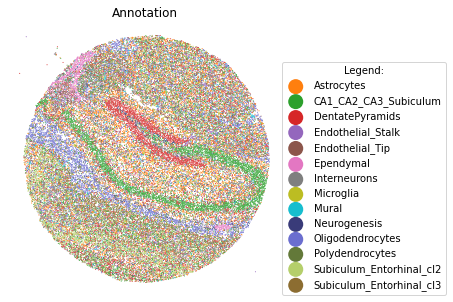

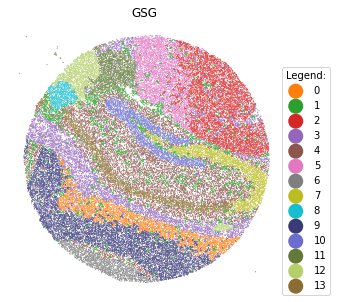

In [5]:
spatial = adata.obsm['spatial']
cell_type = adata.obs['cluster'].values
cell_type_unique = np.unique(cell_type)
plt.figure(figsize=(5, 5))
for i in range(cell_type_unique.shape[0]):
    selection = cell_type == cell_type_unique[i]
    plt.scatter(spatial[selection, 0], spatial[selection, 1], c=hex_colors[2*i+2], s=4, marker='.', edgecolors='none', label=cell_type_unique[i])
plt.gca().set_aspect('equal')
plt.axis('off')
plt.title('Annotation')
plt.legend(title='Legend:', loc=(1, 0), markerscale=15)
plt.show()


spatial = adata.obsm['spatial']
cell_type = adata.obs['GSG_Kmeans_cluster'].values
cell_type_unique = np.unique(cell_type)
plt.figure(figsize=(5, 5))
for i in range(cell_type_unique.shape[0]):
    selection = cell_type == cell_type_unique[i]
    plt.scatter(spatial[selection, 0], spatial[selection, 1], c=hex_colors[2*i+2], s=4, marker='.', edgecolors='none', label=cell_type_unique[i])
plt.gca().set_aspect('equal')
plt.axis('off')
plt.title('GSG')
plt.legend(title='Legend:', loc=(1, 0), markerscale=15)
plt.show()